In [36]:
import sys
import os

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import anndata
import seaborn as sns
import torch
import matplotlib.font_manager
from matplotlib import rcParams
rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})
rcParams.update({'figure.figsize': (3,3)})
rcParams.update({'savefig.dpi': 500})

In [37]:
%load_ext autoreload
%autoreload 2

sys.path.append('../Squidiff2/')
import sample_squidiff

# import plot_util ## the custom plot_util file is completely missing in the code base

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
CUDA_VISIBLE_DEVICES=1

In [38]:
model_path = '/projectnb/ds596/projects/Team 8/checkpoint/diff_data/model.pt' #'diff_results/model.pt'
sampler = sample_squidiff.sampler(
    model_path = model_path, #'diff_results/model.pt',
    gene_size = 203,
    output_dim = 203,
    use_drug_structure = False
)

load model and diffusion...
diffusion num of steps =  1000


In [39]:
import torch
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

Tesla V100-SXM2-16GB
(7, 0)


In [40]:
train_adata = sc.read_h5ad('/projectnb/ds596/projects/Team 8/data/diff_data_fig2/diff_train.h5ad')
z_sem = sampler.model.encoder(
    torch.tensor(train_adata.X).to('cuda')
)

scrnas_pred = sampler.pred(z_sem, gene_size = train_adata.shape[1])
                
x_T = sampler.stochastic_encode(
    sampler.model,
    x = torch.tensor(train_adata.X, dtype = torch.float32).to('cuda'),
    t = 999,
    model_kwargs={'x_start':torch.tensor(train_adata.X, dtype = torch.float32).to('cuda'),
                  'z_mod':z_sem,
    }
)['sample']

In [5]:
CUDA_LAUNCH_BLOCKING=1

In [ ]:
# plot_util script is missing
# plot_util.plot_pca(z_sem,
#                    label = train_adata.obs['Group'],
#                    size = 3, alpha=0.8,
#                    colorlist = ['#3145a8', '#fa2616'],
#                    color_label=[0,3]
#                   )

In [ ]:
# plot_util script is missing
# plot_util.plot_pca(x_T,
#                    label = train_adata.obs['Group'],
#                    size = 3, alpha=0.8,
#                    colorlist = ['#3145a8', '#fa2616'],
#                    color_label=[0,3]
#                   )

## predict day 1-3 from day 0 and direction 

In [41]:
# get the day 0 vector from test data
z_sem = sampler.model.encoder(torch.tensor(train_adata.X).to('cuda'))
# get the represented differentiation latent vector  
direct_z_sem = z_sem[train_adata.obs.Group==3].mean(axis=0) - z_sem[train_adata.obs.Group==0].mean(axis=0)
direct_z_sem = direct_z_sem / (direct_z_sem.norm(p=2) + 1e-8)


In [25]:
direct_z_sem

tensor([ 0.0774, -0.1242,  0.0741,  0.1099, -0.1147, -0.0290, -0.0798, -0.0405,
        -0.0535,  0.2048,  0.0608,  0.0407, -0.1617,  0.0322,  0.0693, -0.0080,
        -0.0436, -0.0261,  0.0368, -0.1060,  0.0939, -0.0460, -0.0286, -0.0861,
        -0.1333,  0.1784,  0.1709, -0.2348,  0.0539, -0.0777,  0.0741,  0.0967,
        -0.0284,  0.1685, -0.2102,  0.1833,  0.1702, -0.1372, -0.1427, -0.2000,
         0.2768,  0.0387,  0.0218,  0.0484, -0.0265, -0.0991,  0.0501,  0.3482,
        -0.1770,  0.0321, -0.0937, -0.0460,  0.0842, -0.2085,  0.2217, -0.1896,
        -0.0262,  0.1934,  0.1093,  0.0738], device='cuda:0',
       grad_fn=<DivBackward0>)

In [42]:
test_adata = sc.read_h5ad('/projectnb/ds596/projects/Team 8/data/diff_data_fig2/diff_test.h5ad')
z_sem_test_day0 = sampler.model.encoder(torch.tensor(test_adata[test_adata.obs['Group']==0].X).to('cuda'))
z_sem_test_day3 = sampler.model.encoder(torch.tensor(test_adata[test_adata.obs['Group']==3].X).to('cuda'))


In [28]:
z_sem_test_day0.shape

torch.Size([600, 60])

In [43]:
r_all = []
pearsonr_all = []

for i in range(6):
    sample_interp0 = sampler.pred(z_sem = z_sem_test_day0,
                                  gene_size = 203,
                                 )
    sample_interp1 = sampler.interp_with_slerp(z_sem_origin = z_sem_test_day0,
                                                   gene_size = 203,
                                                   direction = direct_z_sem,
                                                   scale = 1/3
                                                  )
    sample_interp2 = sampler.interp_with_slerp(z_sem_origin = z_sem_test_day0,
                                                   gene_size = 203,
                                                   direction = direct_z_sem,
                                                   scale = 2/3
                                                  )
    sample_interp3 = sampler.pred(z_sem = z_sem_test_day3,
                                  gene_size = 203,
                                 )
    r2_, pearsonr_ = sampler.cal_metric(sample_interp0, test_adata[test_adata.obs['Group']==0])
    r_all.append(['squidiff',i,'day0',r2_])
    pearsonr_all.append(['squidiff',i,'day0',pearsonr_])
    r2_, pearsonr_ = sampler.cal_metric(sample_interp1, test_adata[test_adata.obs['Group']==1])
    r_all.append(['squidiff',i,'day1',r2_])
    pearsonr_all.append(['squidiff',i,'day1',pearsonr_])
    r2_, pearsonr_ = sampler.cal_metric(sample_interp2,  test_adata[test_adata.obs['Group']==2])
    r_all.append(['squidiff',i,'day2',r2_])
    pearsonr_all.append(['squidiff',i,'day2',pearsonr_])
    r2_, pearsonr_ = sampler.cal_metric(sample_interp3, test_adata[test_adata.obs['Group']==3])
    r_all.append(['squidiff',i,'day3',r2_])
    pearsonr_all.append(['squidiff',i,'day3',pearsonr_])
    
# pd.DataFrame(r_all).to_csv('/hpc/mydata/siyu.he/Siyu_projects/Squidiff_reproducibility/fig2_diff_r_all_new.csv')
# pd.DataFrame(pearsonr_all).to_csv('/hpc/mydata/siyu.he/Siyu_projects/Squidiff_reproducibility/fig2_diff_pearsonr_all_new.csv')


In [44]:
z_sem_test_day1 = sampler.model.encoder(torch.tensor(sample_interp1).to('cuda'))
sample_interp4 = sampler.interp_with_slerp(z_sem_origin = z_sem_test_day1,
                                                   gene_size = 203,
                                                   direction = direct_z_sem,
                                                   scale = 1/3)

Text(0.1, 0.9, 'Pearsonr= 0.808')

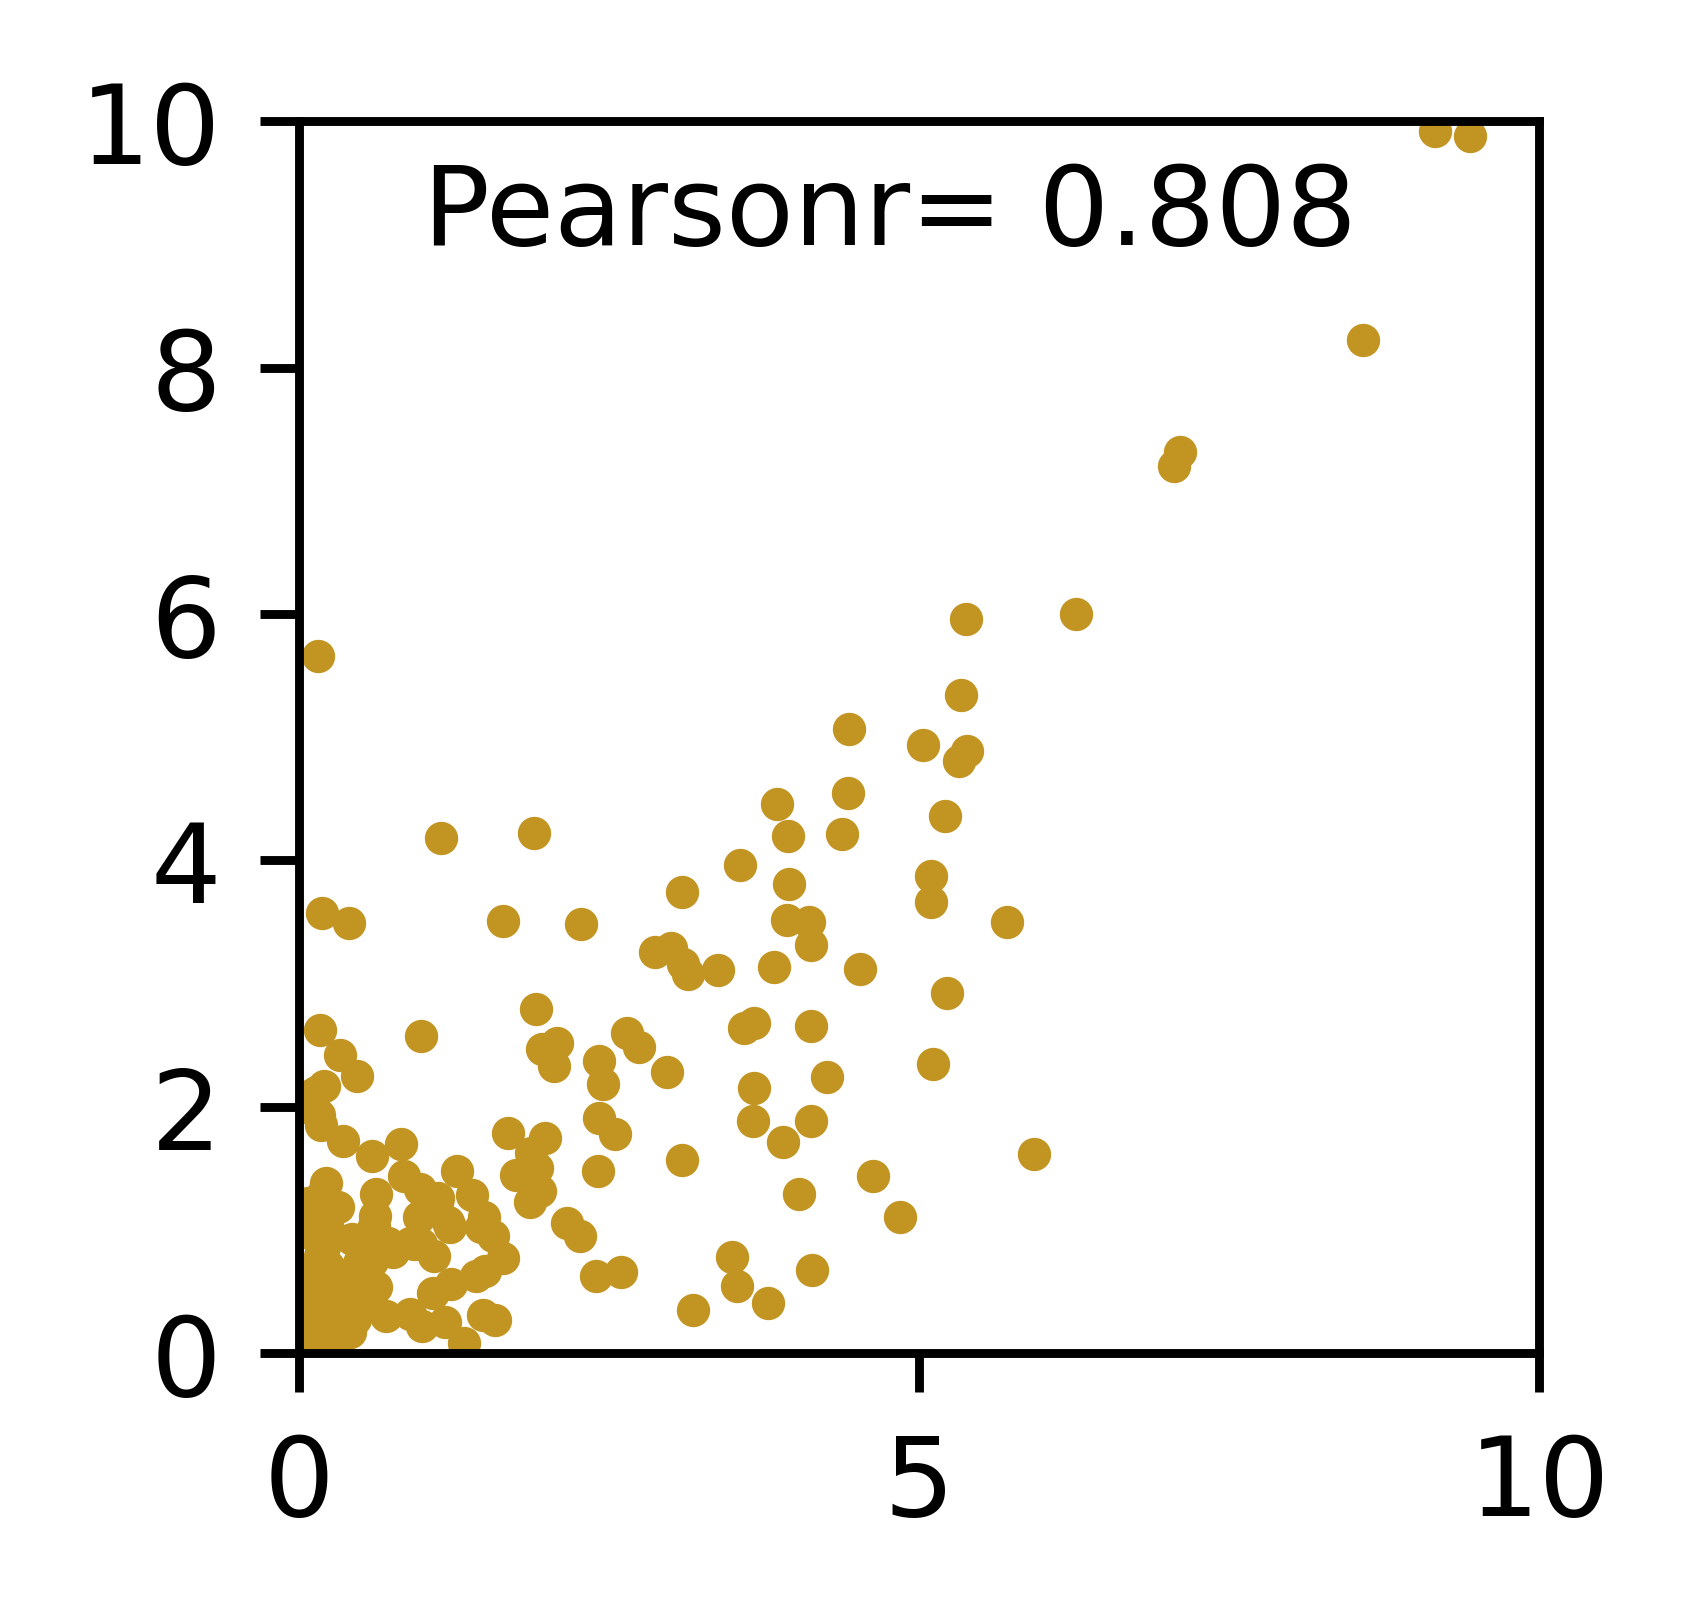

In [45]:
# d1 -> d2
from scipy.stats import pearsonr
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp4.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==2].X.mean(axis=0),
            s=4,
            c='#c29523'
           )
plt.xlim([0,10])
plt.ylim([0,10])

sampler.cal_metric(sample_interp2, test_adata[test_adata.obs['Group']==2])
# add person correlation coefficient in the plot
r, p = pearsonr(sample_interp2.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==2].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

Text(0.1, 0.9, 'Pearsonr= 0.808')

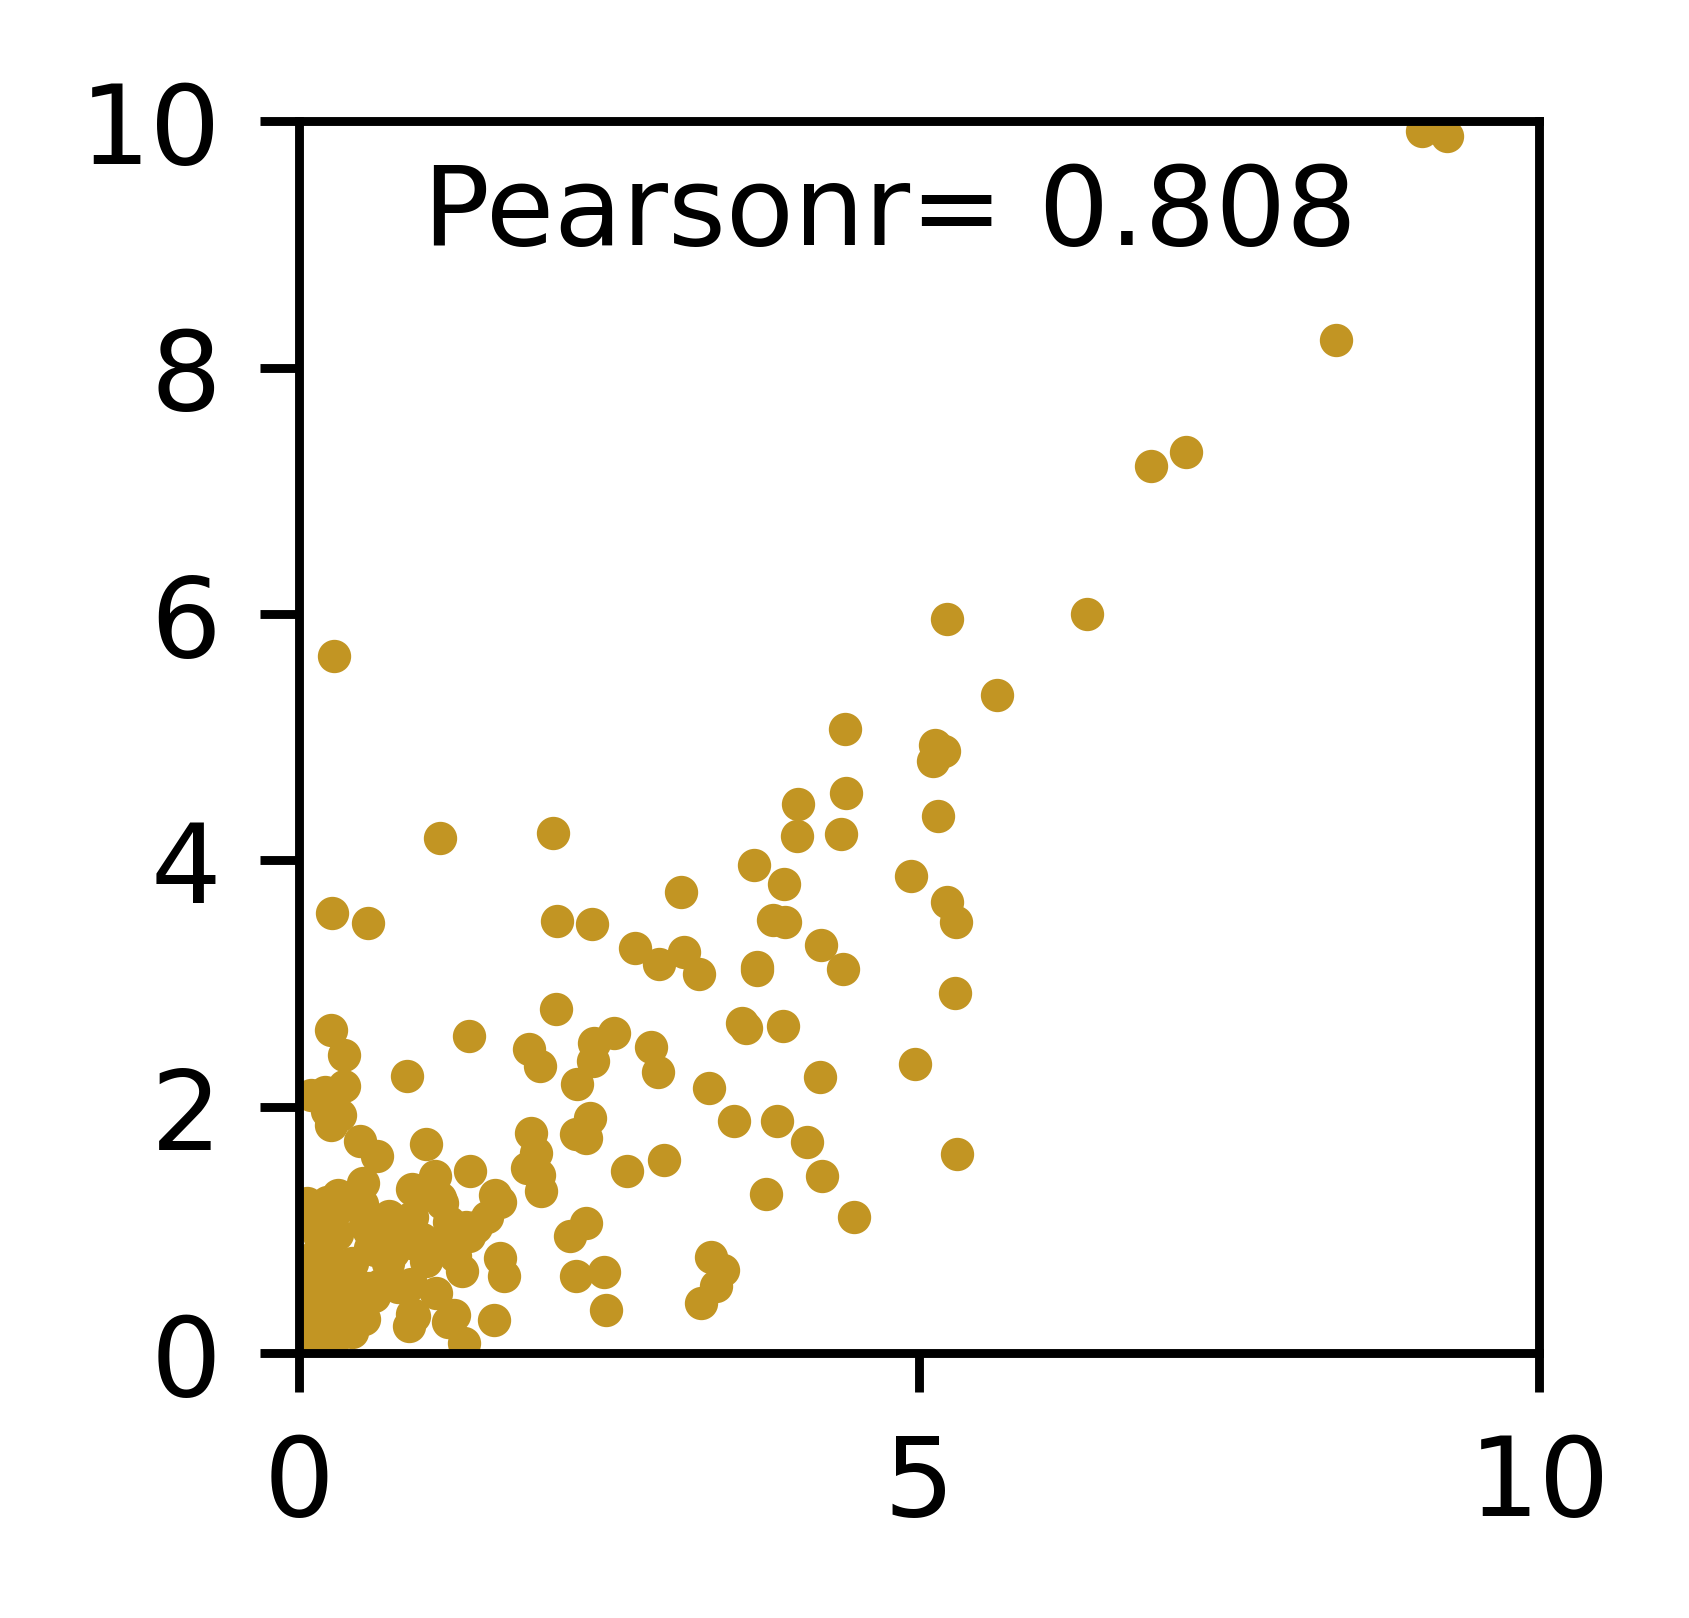

In [46]:
# d0 -> d2
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp2.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==2].X.mean(axis=0),
            s=4,
            c='#c29523'
           )
plt.xlim([0,10])
plt.ylim([0,10])

sampler.cal_metric(sample_interp2, test_adata[test_adata.obs['Group']==2])
# add person correlation coefficient in the plot
r, p = pearsonr(sample_interp2.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==2].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

Text(0.1, 0.9, 'Pearsonr= 0.892')

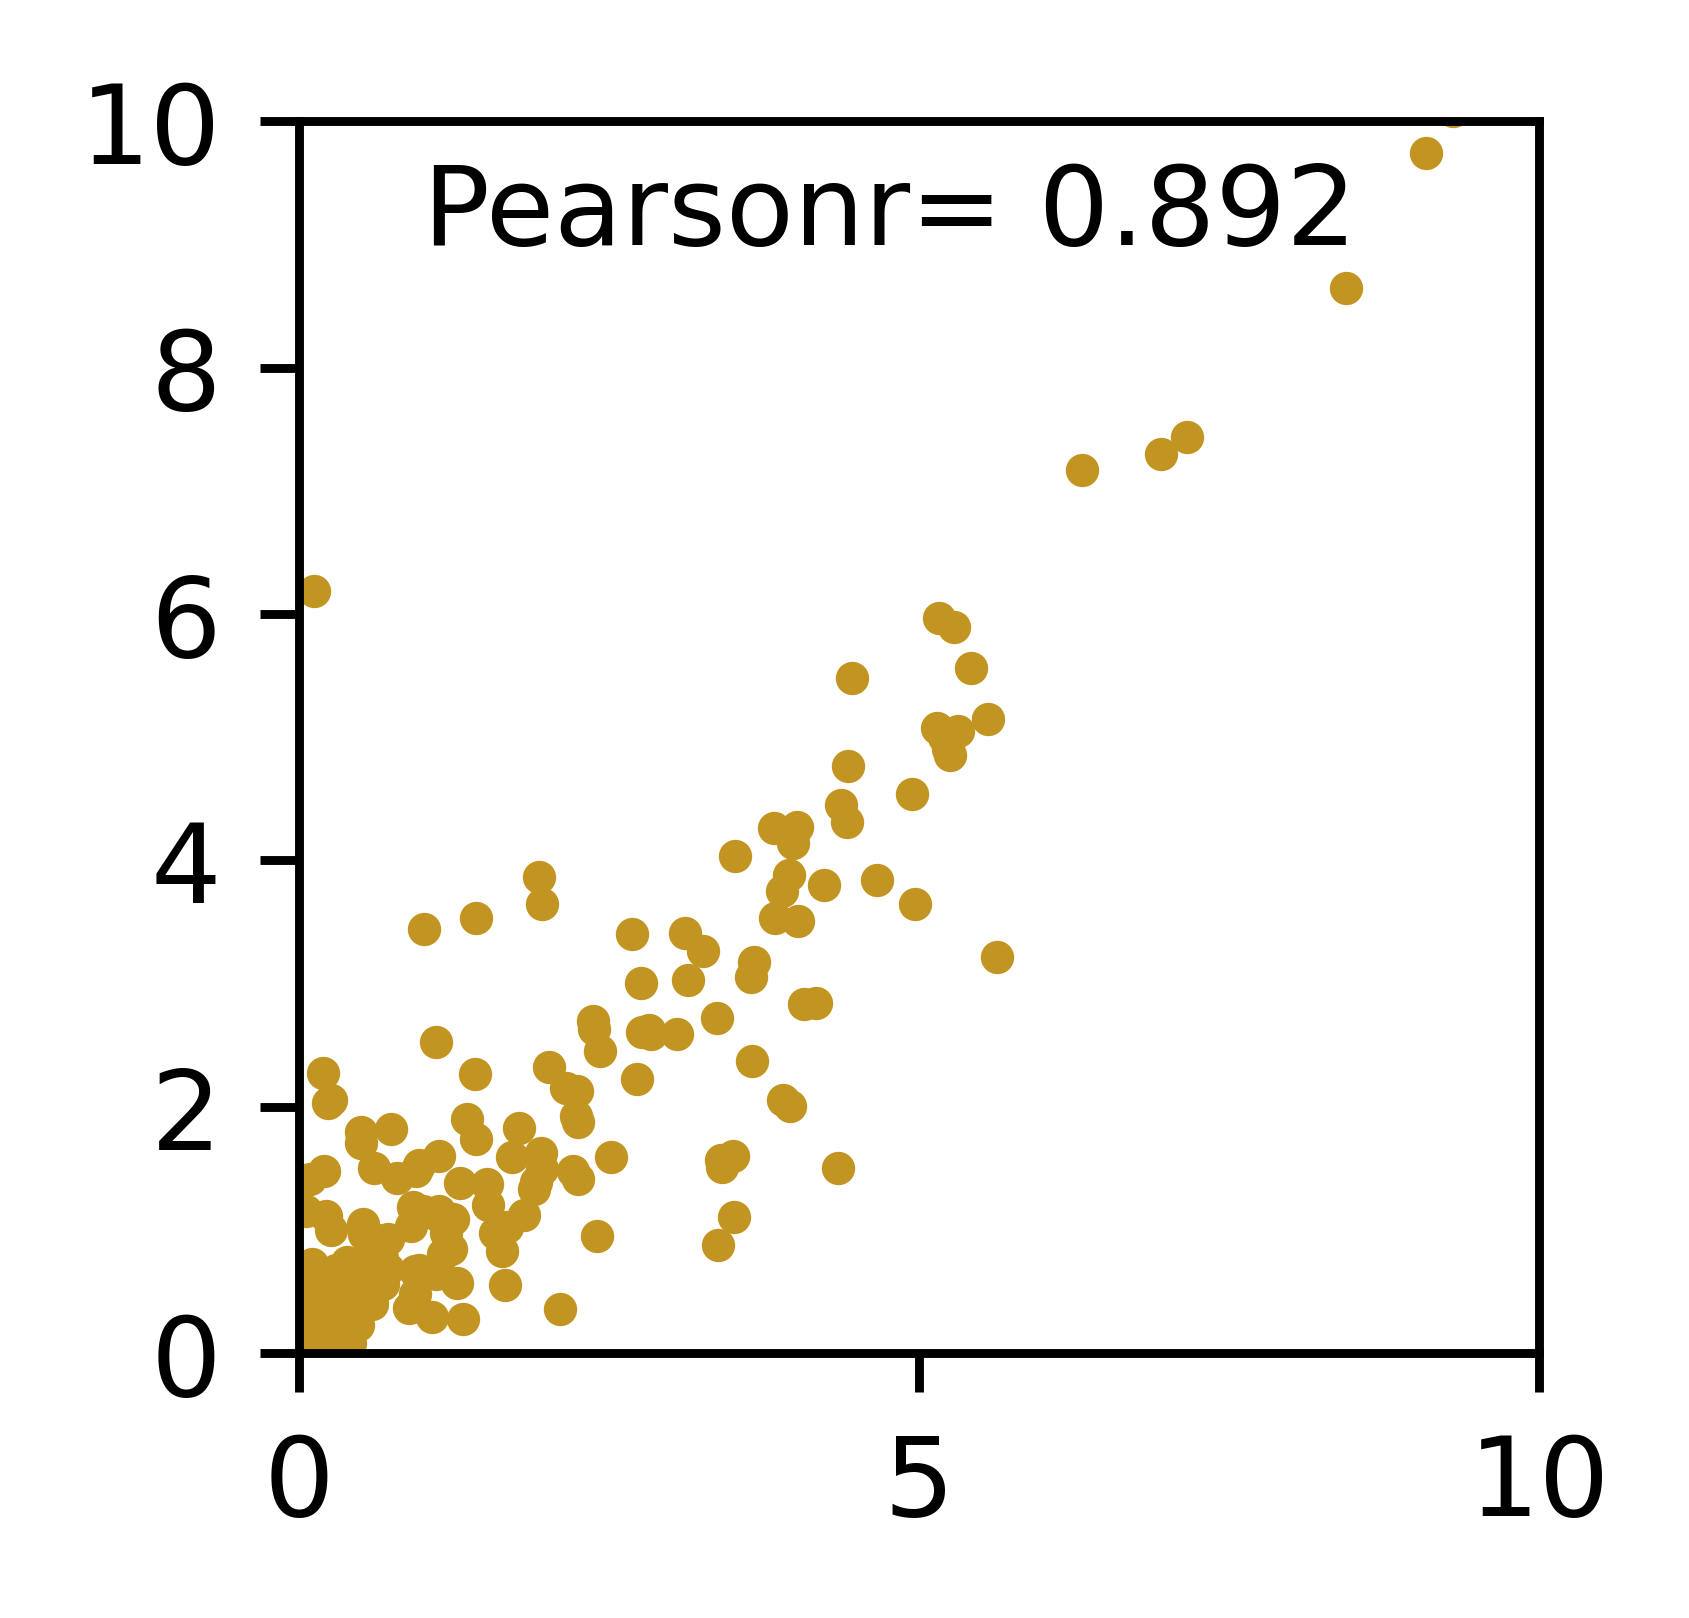

In [47]:
# d0 -> d1
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp1.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==1].X.mean(axis=0),
            s=4,
            c='#c29523'
           )
plt.xlim([0,10])
plt.ylim([0,10])

sampler.cal_metric(sample_interp1, test_adata[test_adata.obs['Group']==1])
# add person correlation coefficient in the plot
r, p = pearsonr(sample_interp1.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==1].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

Text(0.1, 0.9, 'Pearsonr= 0.998')

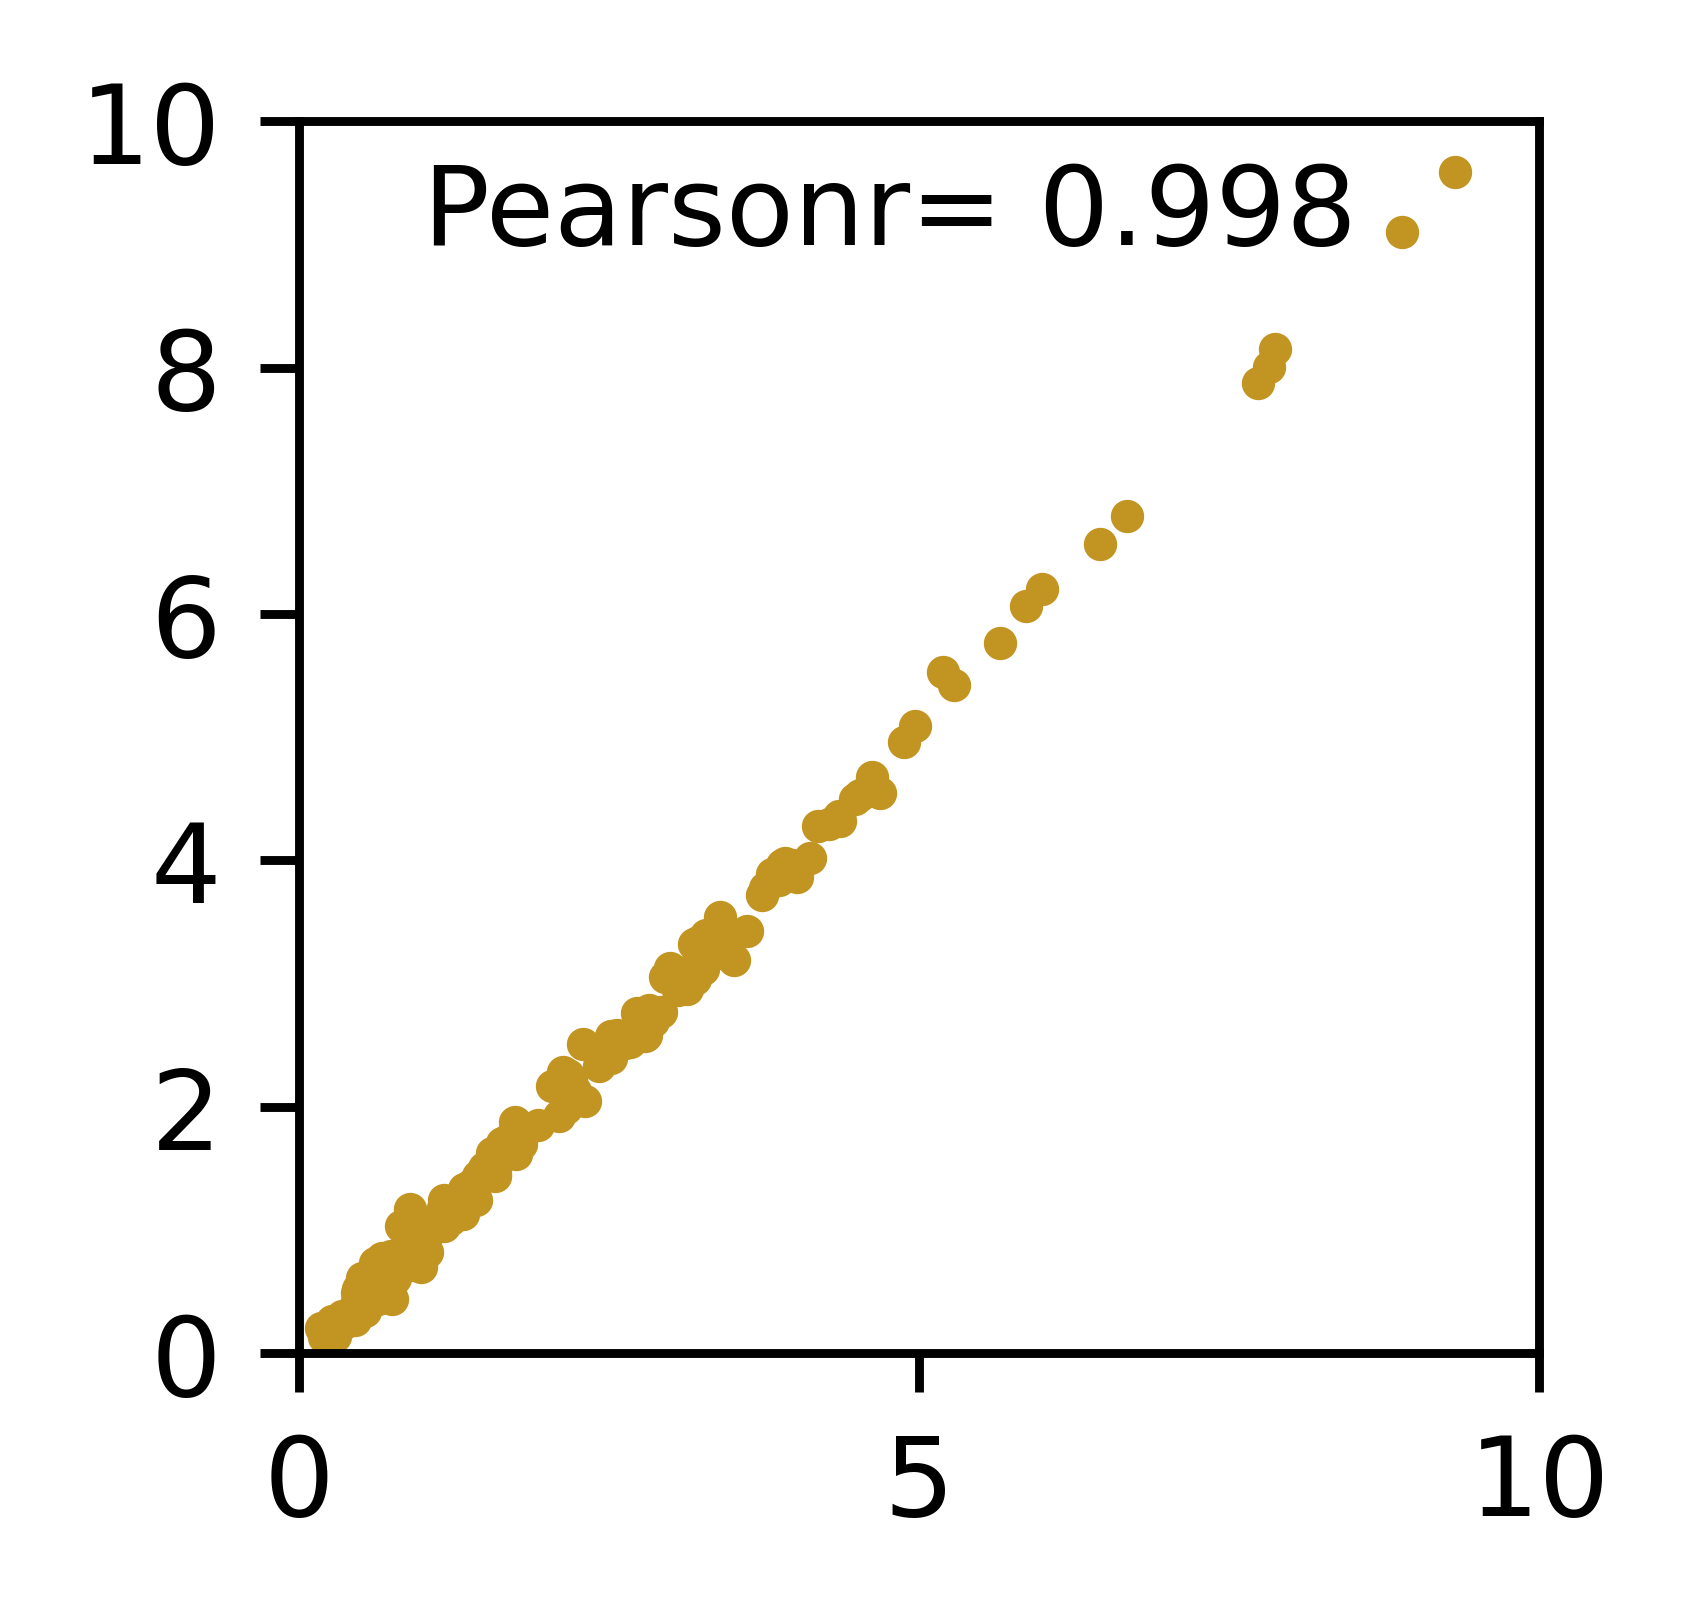

In [48]:
# d0 -> d3
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp3.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==3].X.mean(axis=0),
            s=4,
            c='#c29523'
           )
plt.xlim([0,10])
plt.ylim([0,10])

sampler.cal_metric(sample_interp3, test_adata[test_adata.obs['Group']==3])
# add person correlation coefficiente in the plot
r, p = pearsonr(sample_interp3.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==3].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

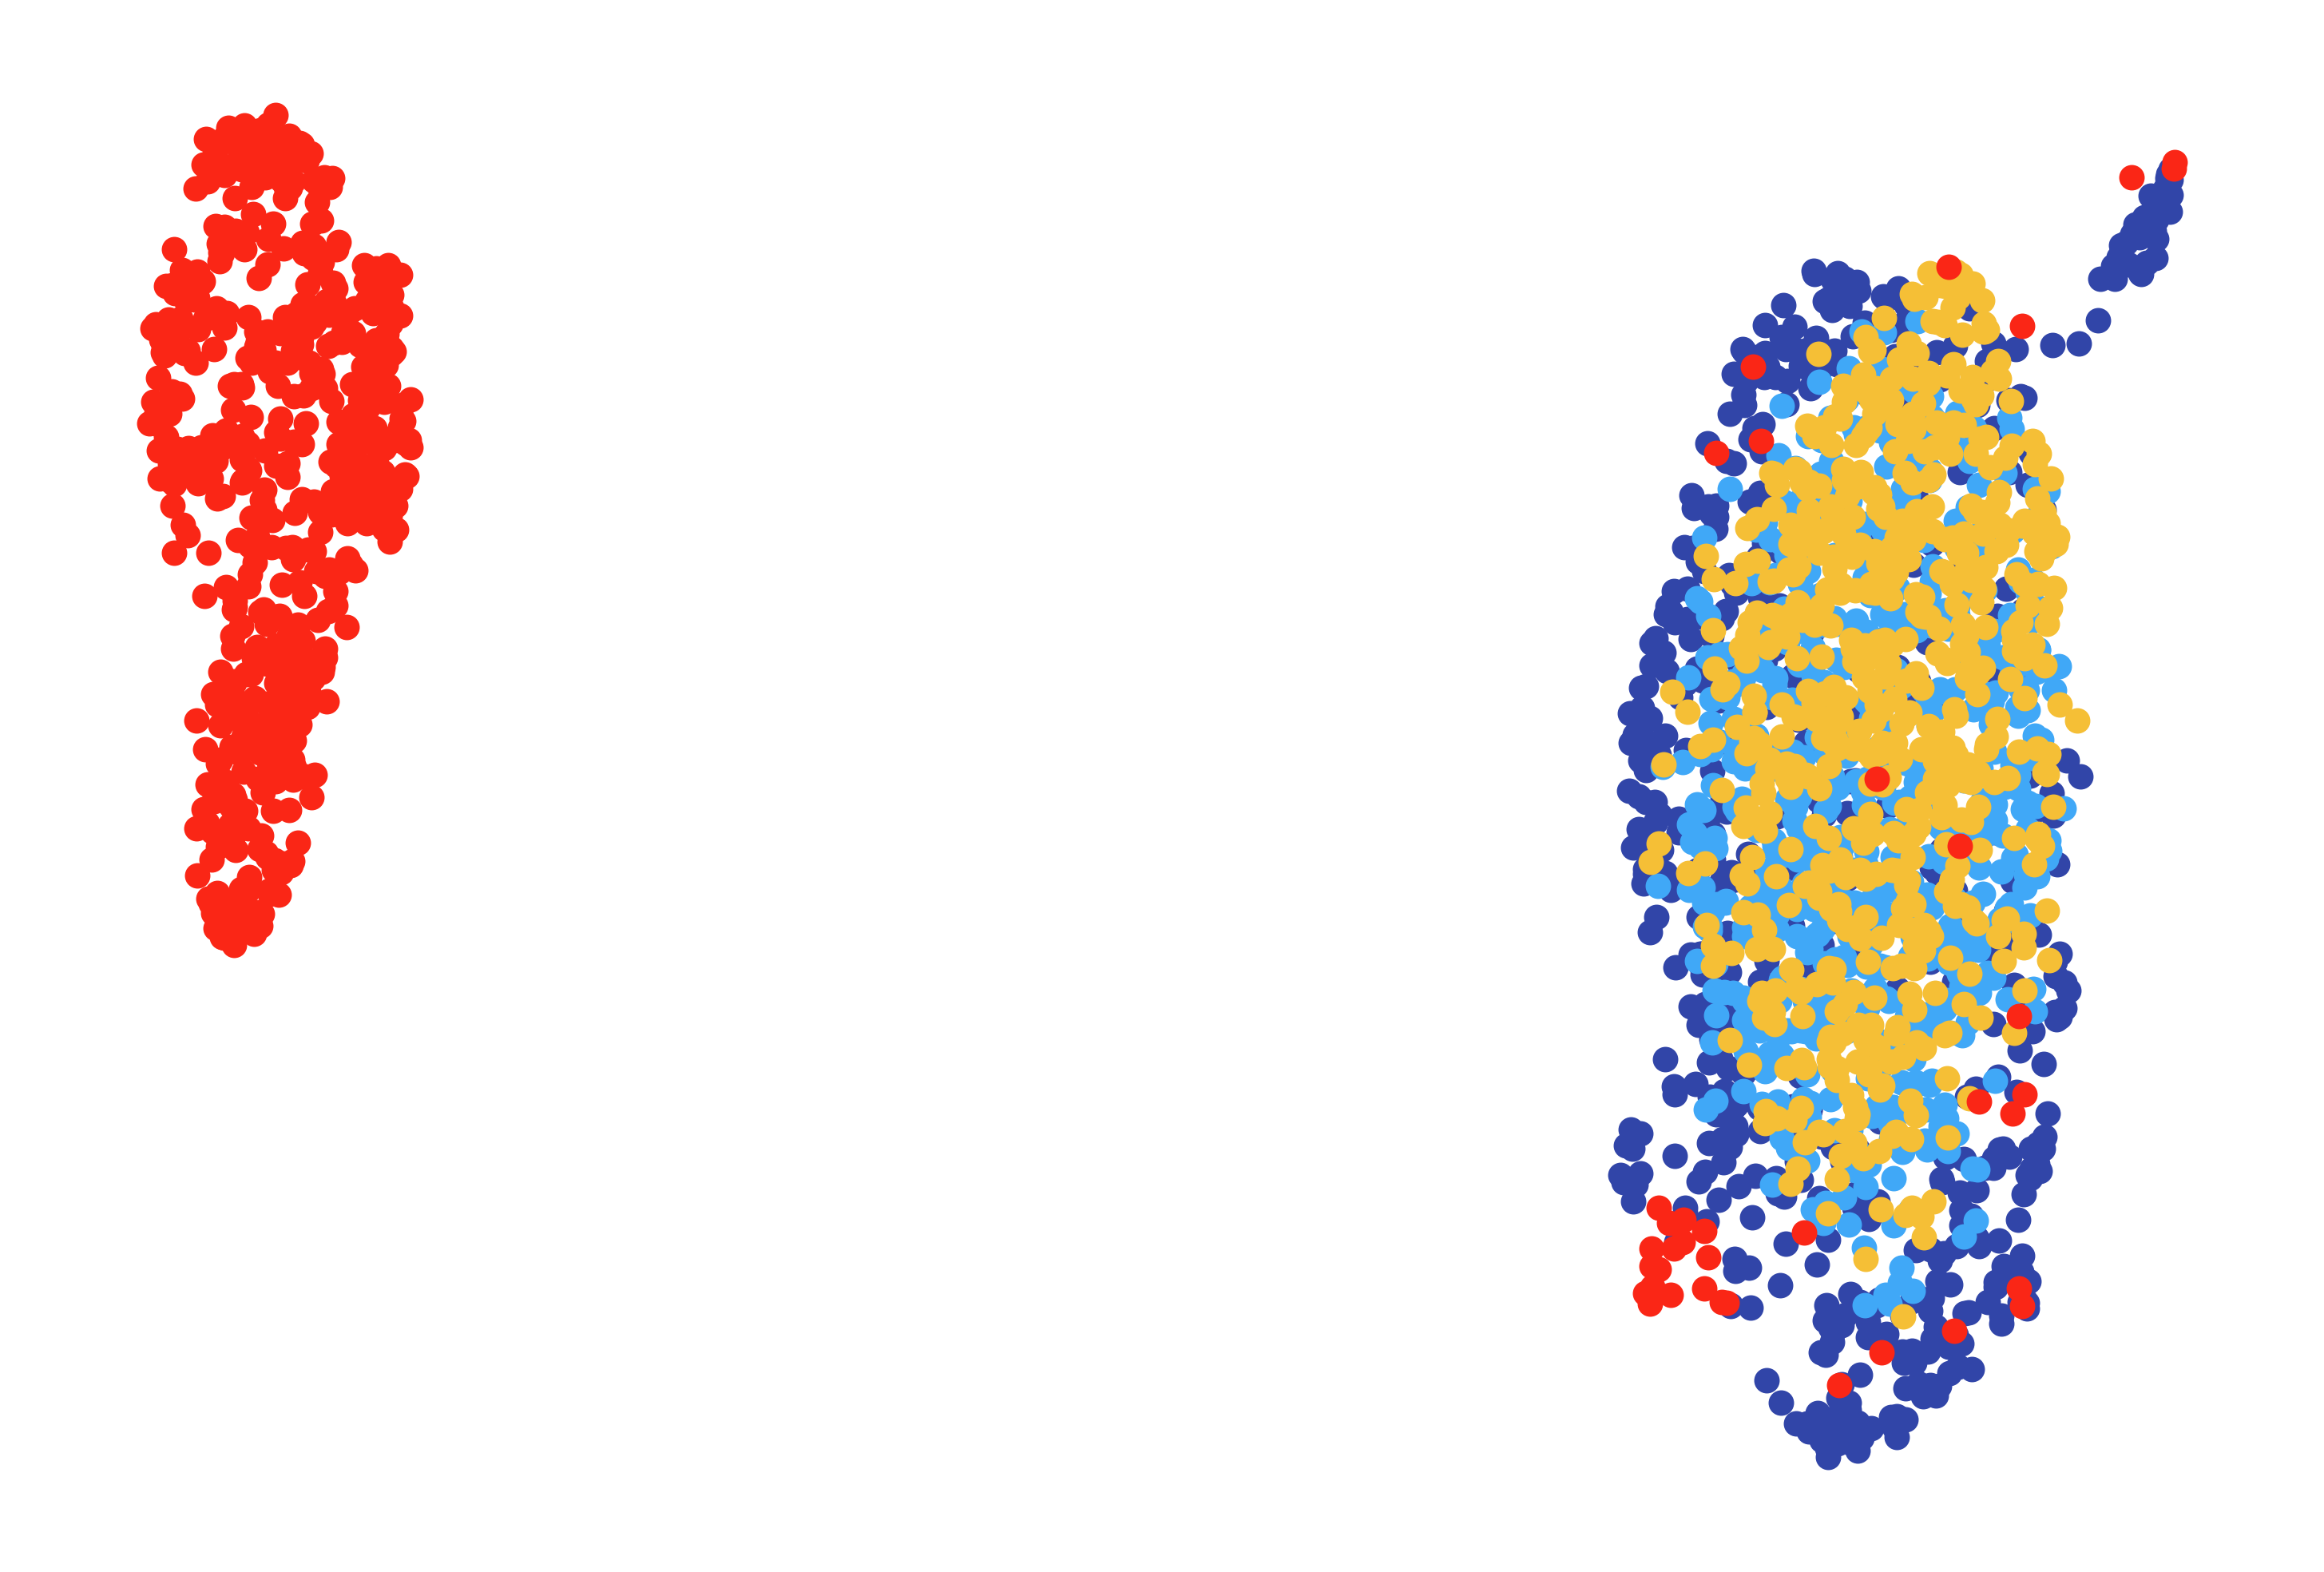

In [49]:
# Combine all points
from sklearn.decomposition import PCA
import umap
combined_points = np.concatenate([sample_interp0.detach().cpu().numpy(),
                                  sample_interp1.detach().cpu().numpy(),
                                  sample_interp2.detach().cpu().numpy(),
                                  sample_interp3.detach().cpu().numpy(),
                                 ], axis=0)
combined_labels  = np.array([0]*600+[1]*600+[2]*600+[3]*600)

pca = PCA(n_components=30)  # You can adjust the number of components
pca_result = pca.fit_transform(combined_points)
#pca_result

# Perform UMAP with increased neighbors
reducer = umap.UMAP(n_neighbors=50, min_dist=0.2, n_components=2)
embedding_combined = reducer.fit_transform(pca_result)

# Plotting
plt.figure(figsize=(6, 4), dpi=600)
colorlist = ['#3145a8', '#40a8f7', '#f5bf36', '#fa2616']  # Green and Magenta for interpolated points
for i in range(4):
    plt.scatter(embedding_combined[combined_labels == i, 0], 
                embedding_combined[combined_labels == i, 1], 
                c=colorlist[i], 
                s=8, 
                alpha=1)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.axis('off')
#plt.title('UMAP with Linear Interpolation between day0 and day3')
plt.show()

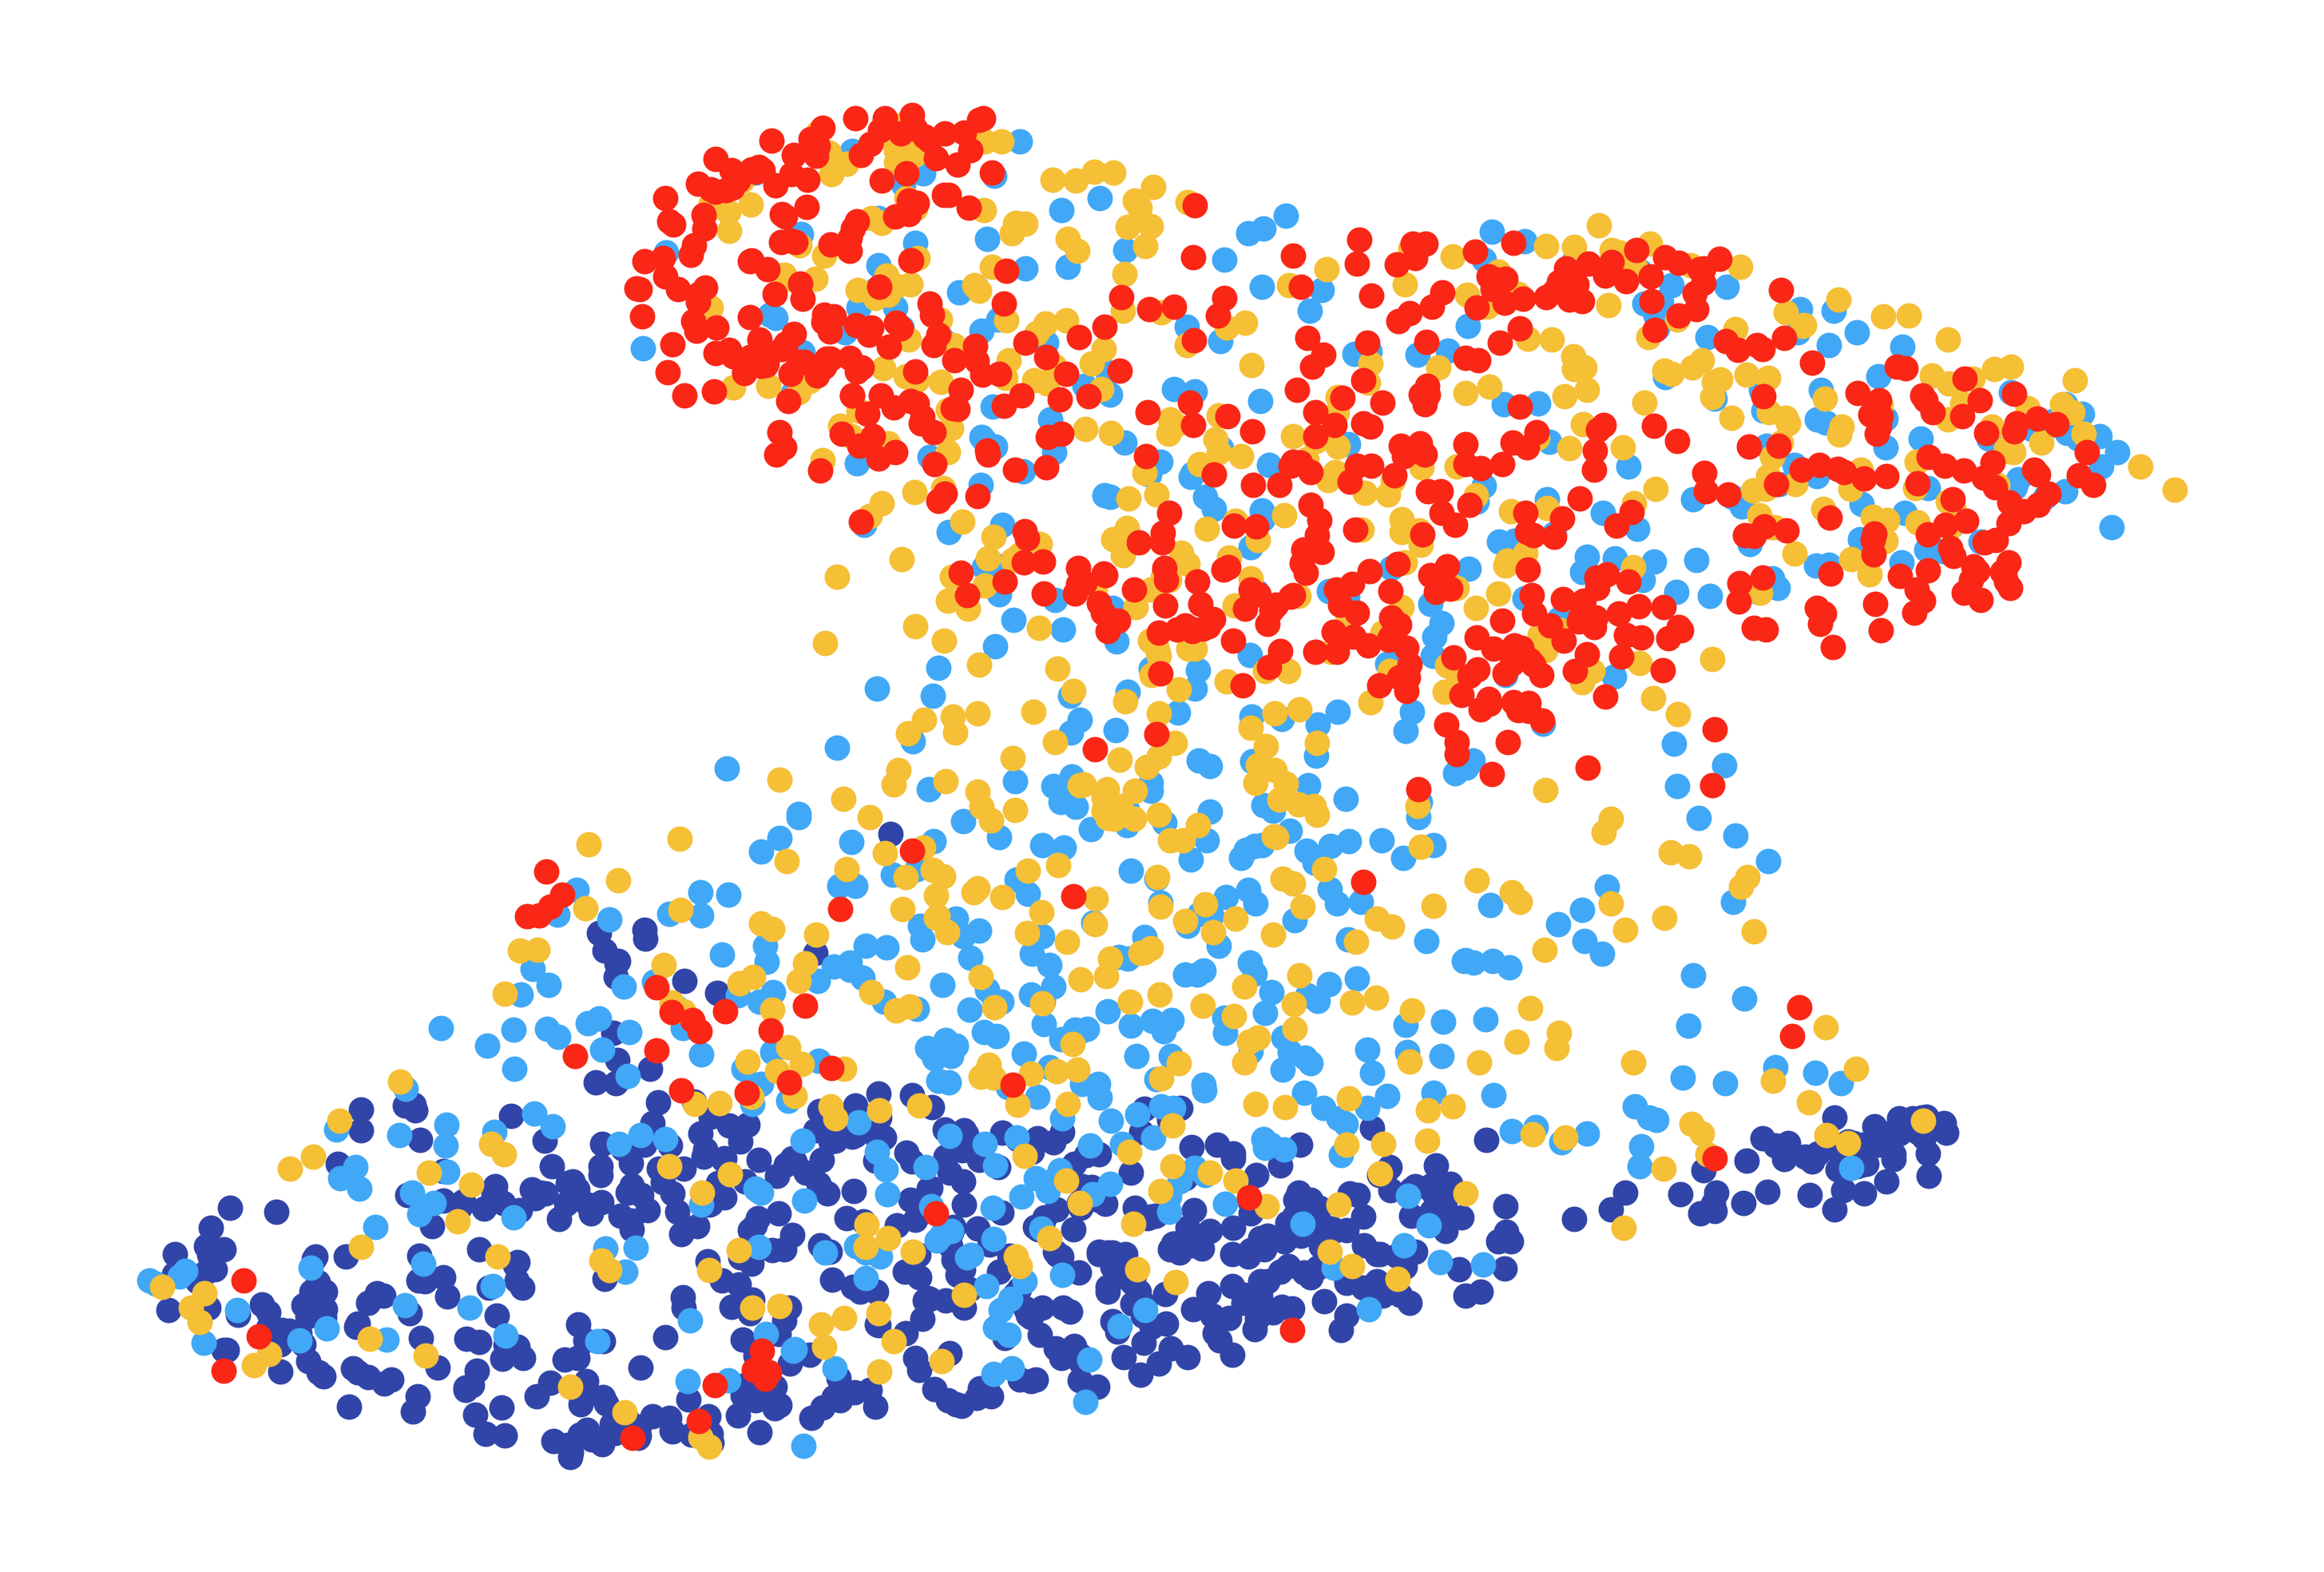

In [38]:
# Combine all points
from sklearn.decomposition import PCA
import umap
combined_points = np.concatenate([sample_interp0.detach().cpu().numpy(),
                                  sample_interp1.detach().cpu().numpy(),
                                  sample_interp2.detach().cpu().numpy(),
                                  sample_interp3.detach().cpu().numpy(),
                                 ], axis=0)
combined_labels  = np.array([0]*600+[1]*600+[2]*600+[3]*600)

pca = PCA(n_components=30)  # You can adjust the number of components
pca_result = pca.fit_transform(combined_points)
#pca_result

# Perform UMAP with increased neighbors
reducer = umap.UMAP(n_neighbors=50, min_dist=0.2, n_components=2)
embedding_combined = reducer.fit_transform(pca_result)

# Plotting
plt.figure(figsize=(6, 4), dpi=600)
colorlist = ['#3145a8', '#40a8f7', '#f5bf36', '#fa2616']  # Green and Magenta for interpolated points
for i in range(4):
    plt.scatter(embedding_combined[combined_labels == i, 0], 
                embedding_combined[combined_labels == i, 1], 
                c=colorlist[i], 
                s=8, 
                alpha=1)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.axis('off')
#plt.title('UMAP with Linear Interpolation between day0 and day3')
plt.show()


In [39]:
sampler.cal_metric(sample_interp0, test_adata[test_adata.obs['Group']==0])


(0.9982692050270627, 0.9993994425976916)

In [40]:
sampler.cal_metric(sample_interp1, test_adata[test_adata.obs['Group']==1])


(0.4818542101815815, 0.8563425118158279)

In [41]:
sampler.cal_metric(sample_interp2, test_adata[test_adata.obs['Group']==2])

(0.5500887371736206, 0.9150572118306162)

In [42]:
sampler.cal_metric(sample_interp3, test_adata[test_adata.obs['Group']==3])

(0.9952211159576472, 0.9982799145050907)

In [43]:
pred_tensor =np.array( torch.cat([sample_interp0,sample_interp1,sample_interp2,sample_interp3], dim=0).detach().cpu())
all_new_data = anndata.AnnData(pred_tensor)
all_new_data.obs['weights'] = combined_labels
all_new_data.obs['weights'] = all_new_data.obs['weights'].astype(str).astype('category')
all_new_data.var_names = test_adata.var_names

sc.tl.rank_genes_groups(all_new_data, groupby='weights', method='wilcoxon')
all_new_data.layers['scaled'] = sc.pp.scale(all_new_data, copy=True).X
marker_genes_dict = {
    '0.0': ['T', 'GATA6','NANOG'],
}

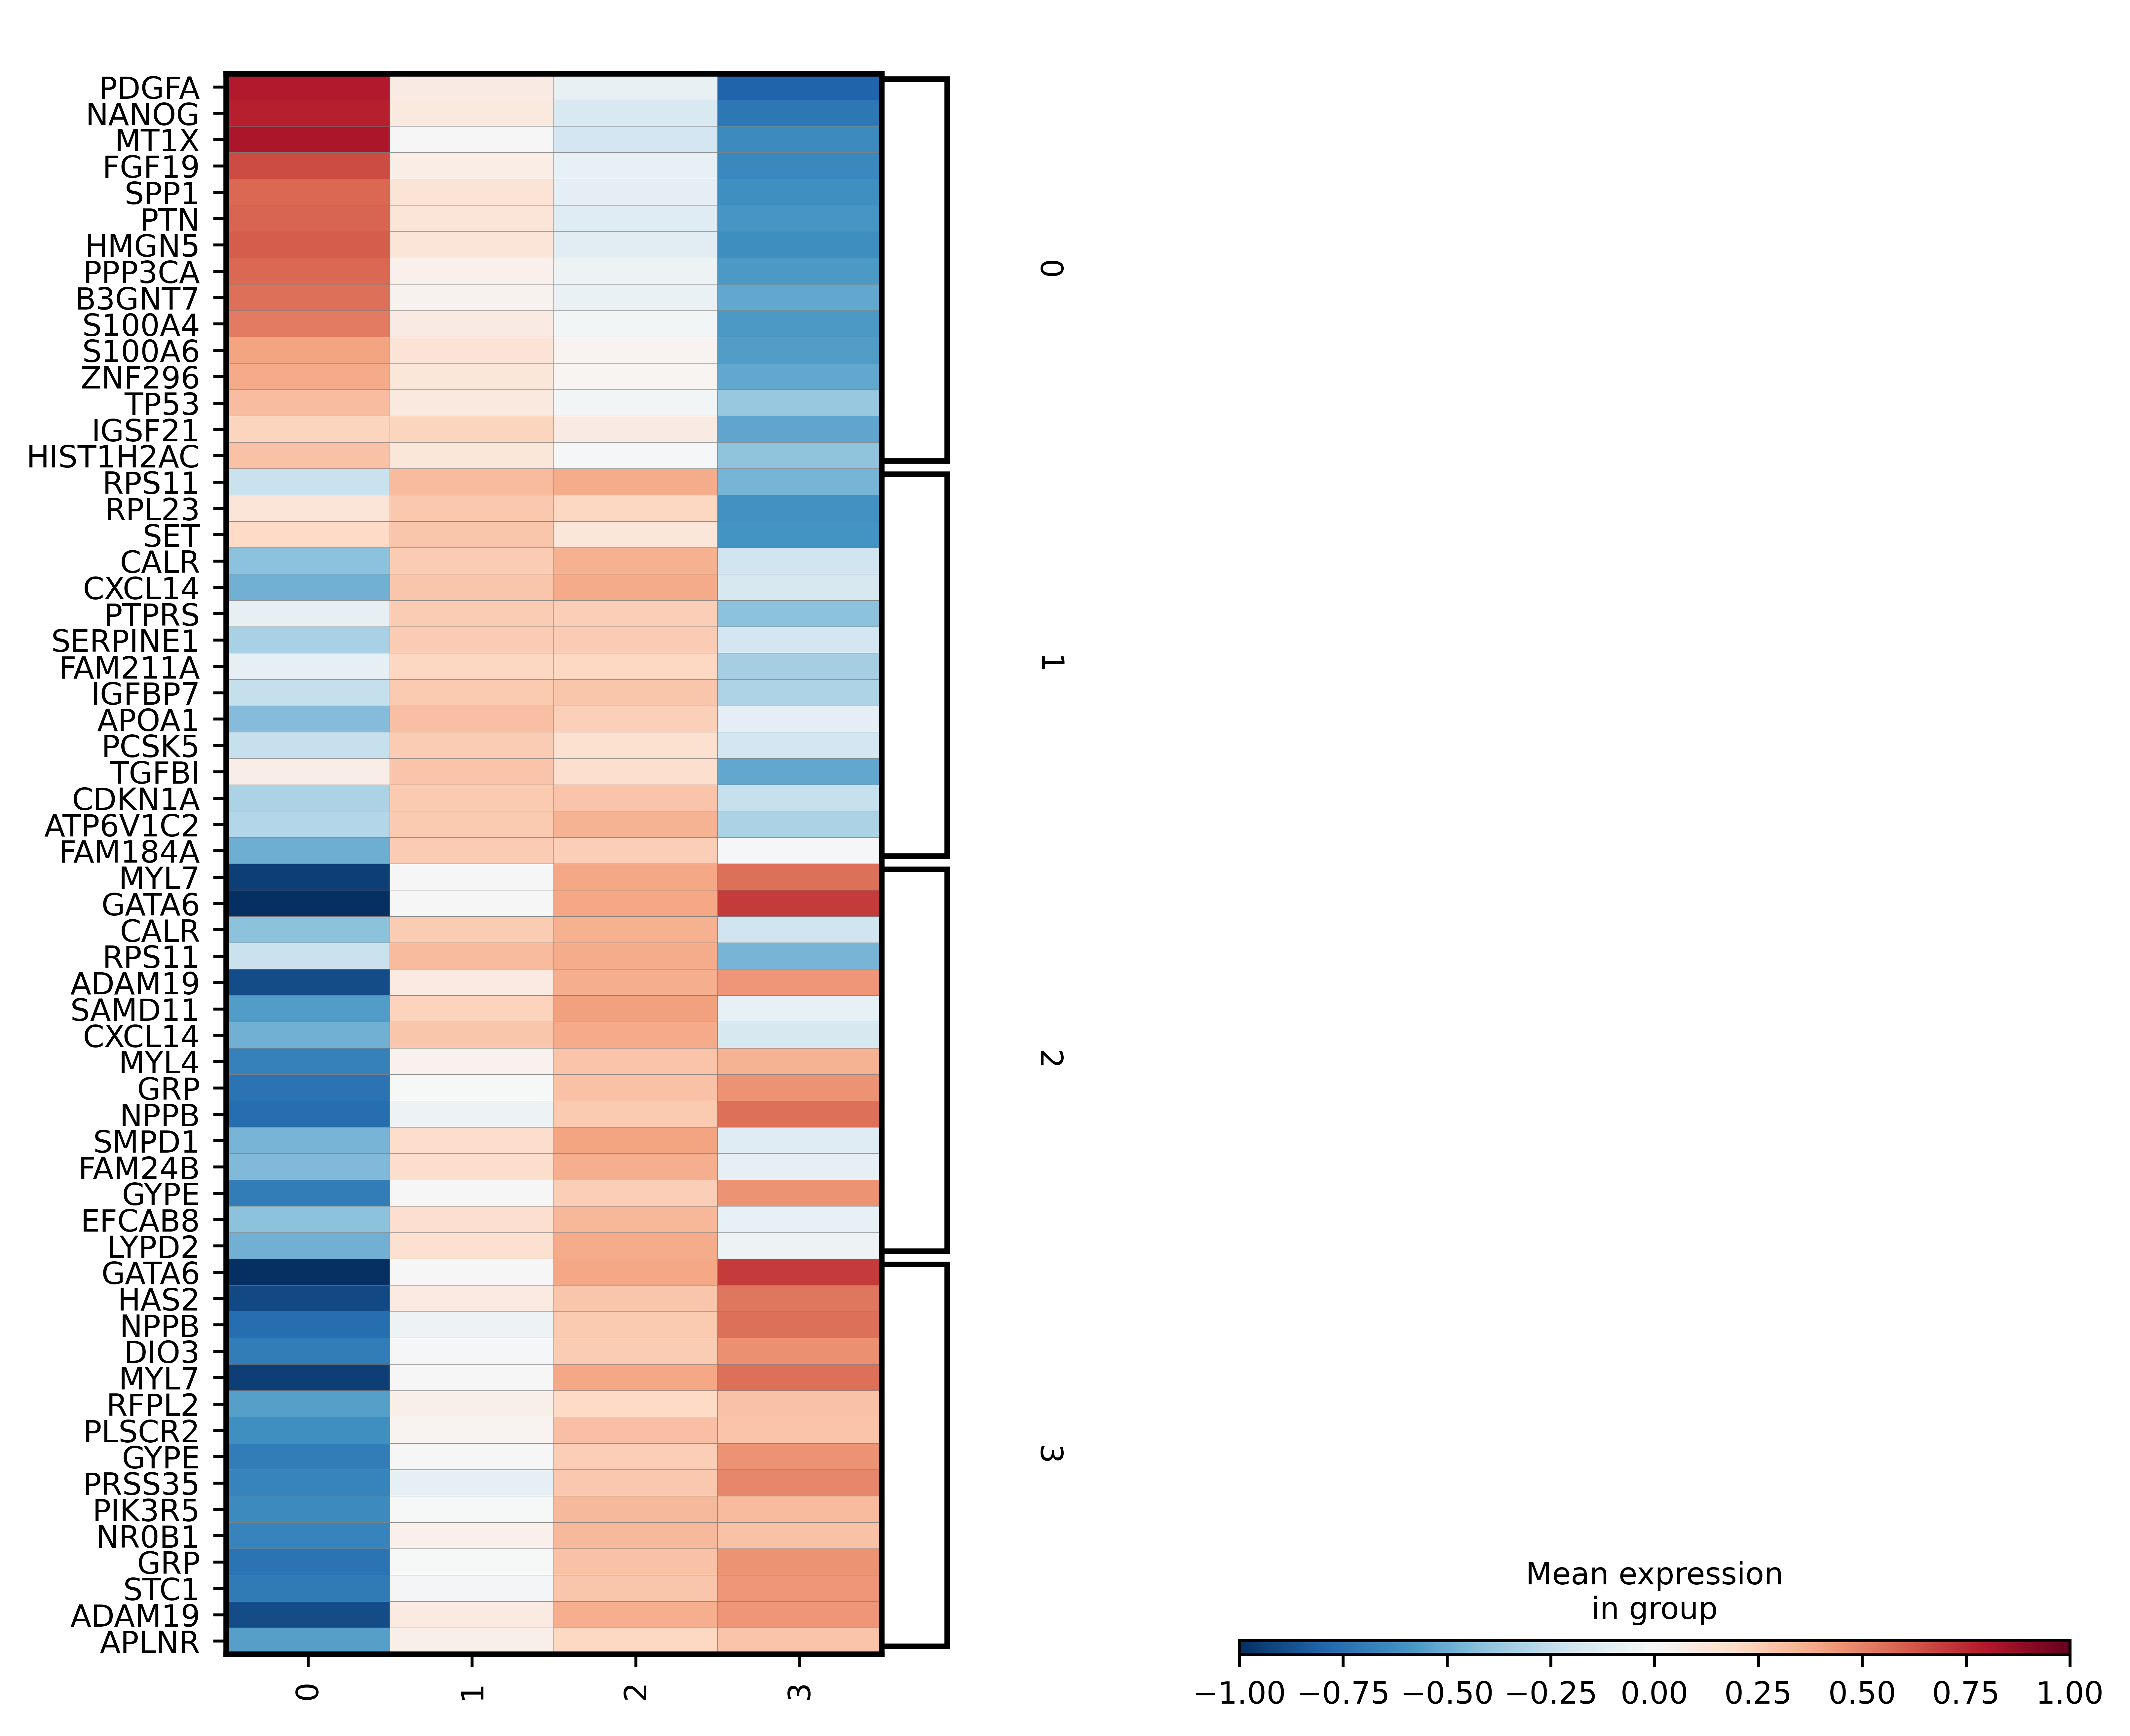

In [44]:
fig,ax = plt.subplots(figsize =(9,8),dpi=800)
sc.pl.rank_genes_groups_matrixplot(all_new_data, 
                                dendrogram=False,
                                n_genes=15, 
                                   use_raw=False, 
                                swap_axes=True, 
                                vmin=-1, vmax=1, 
                                cmap='RdBu_r', 
                                layer='scaled', 
                                   ax=ax,
                                show=True)

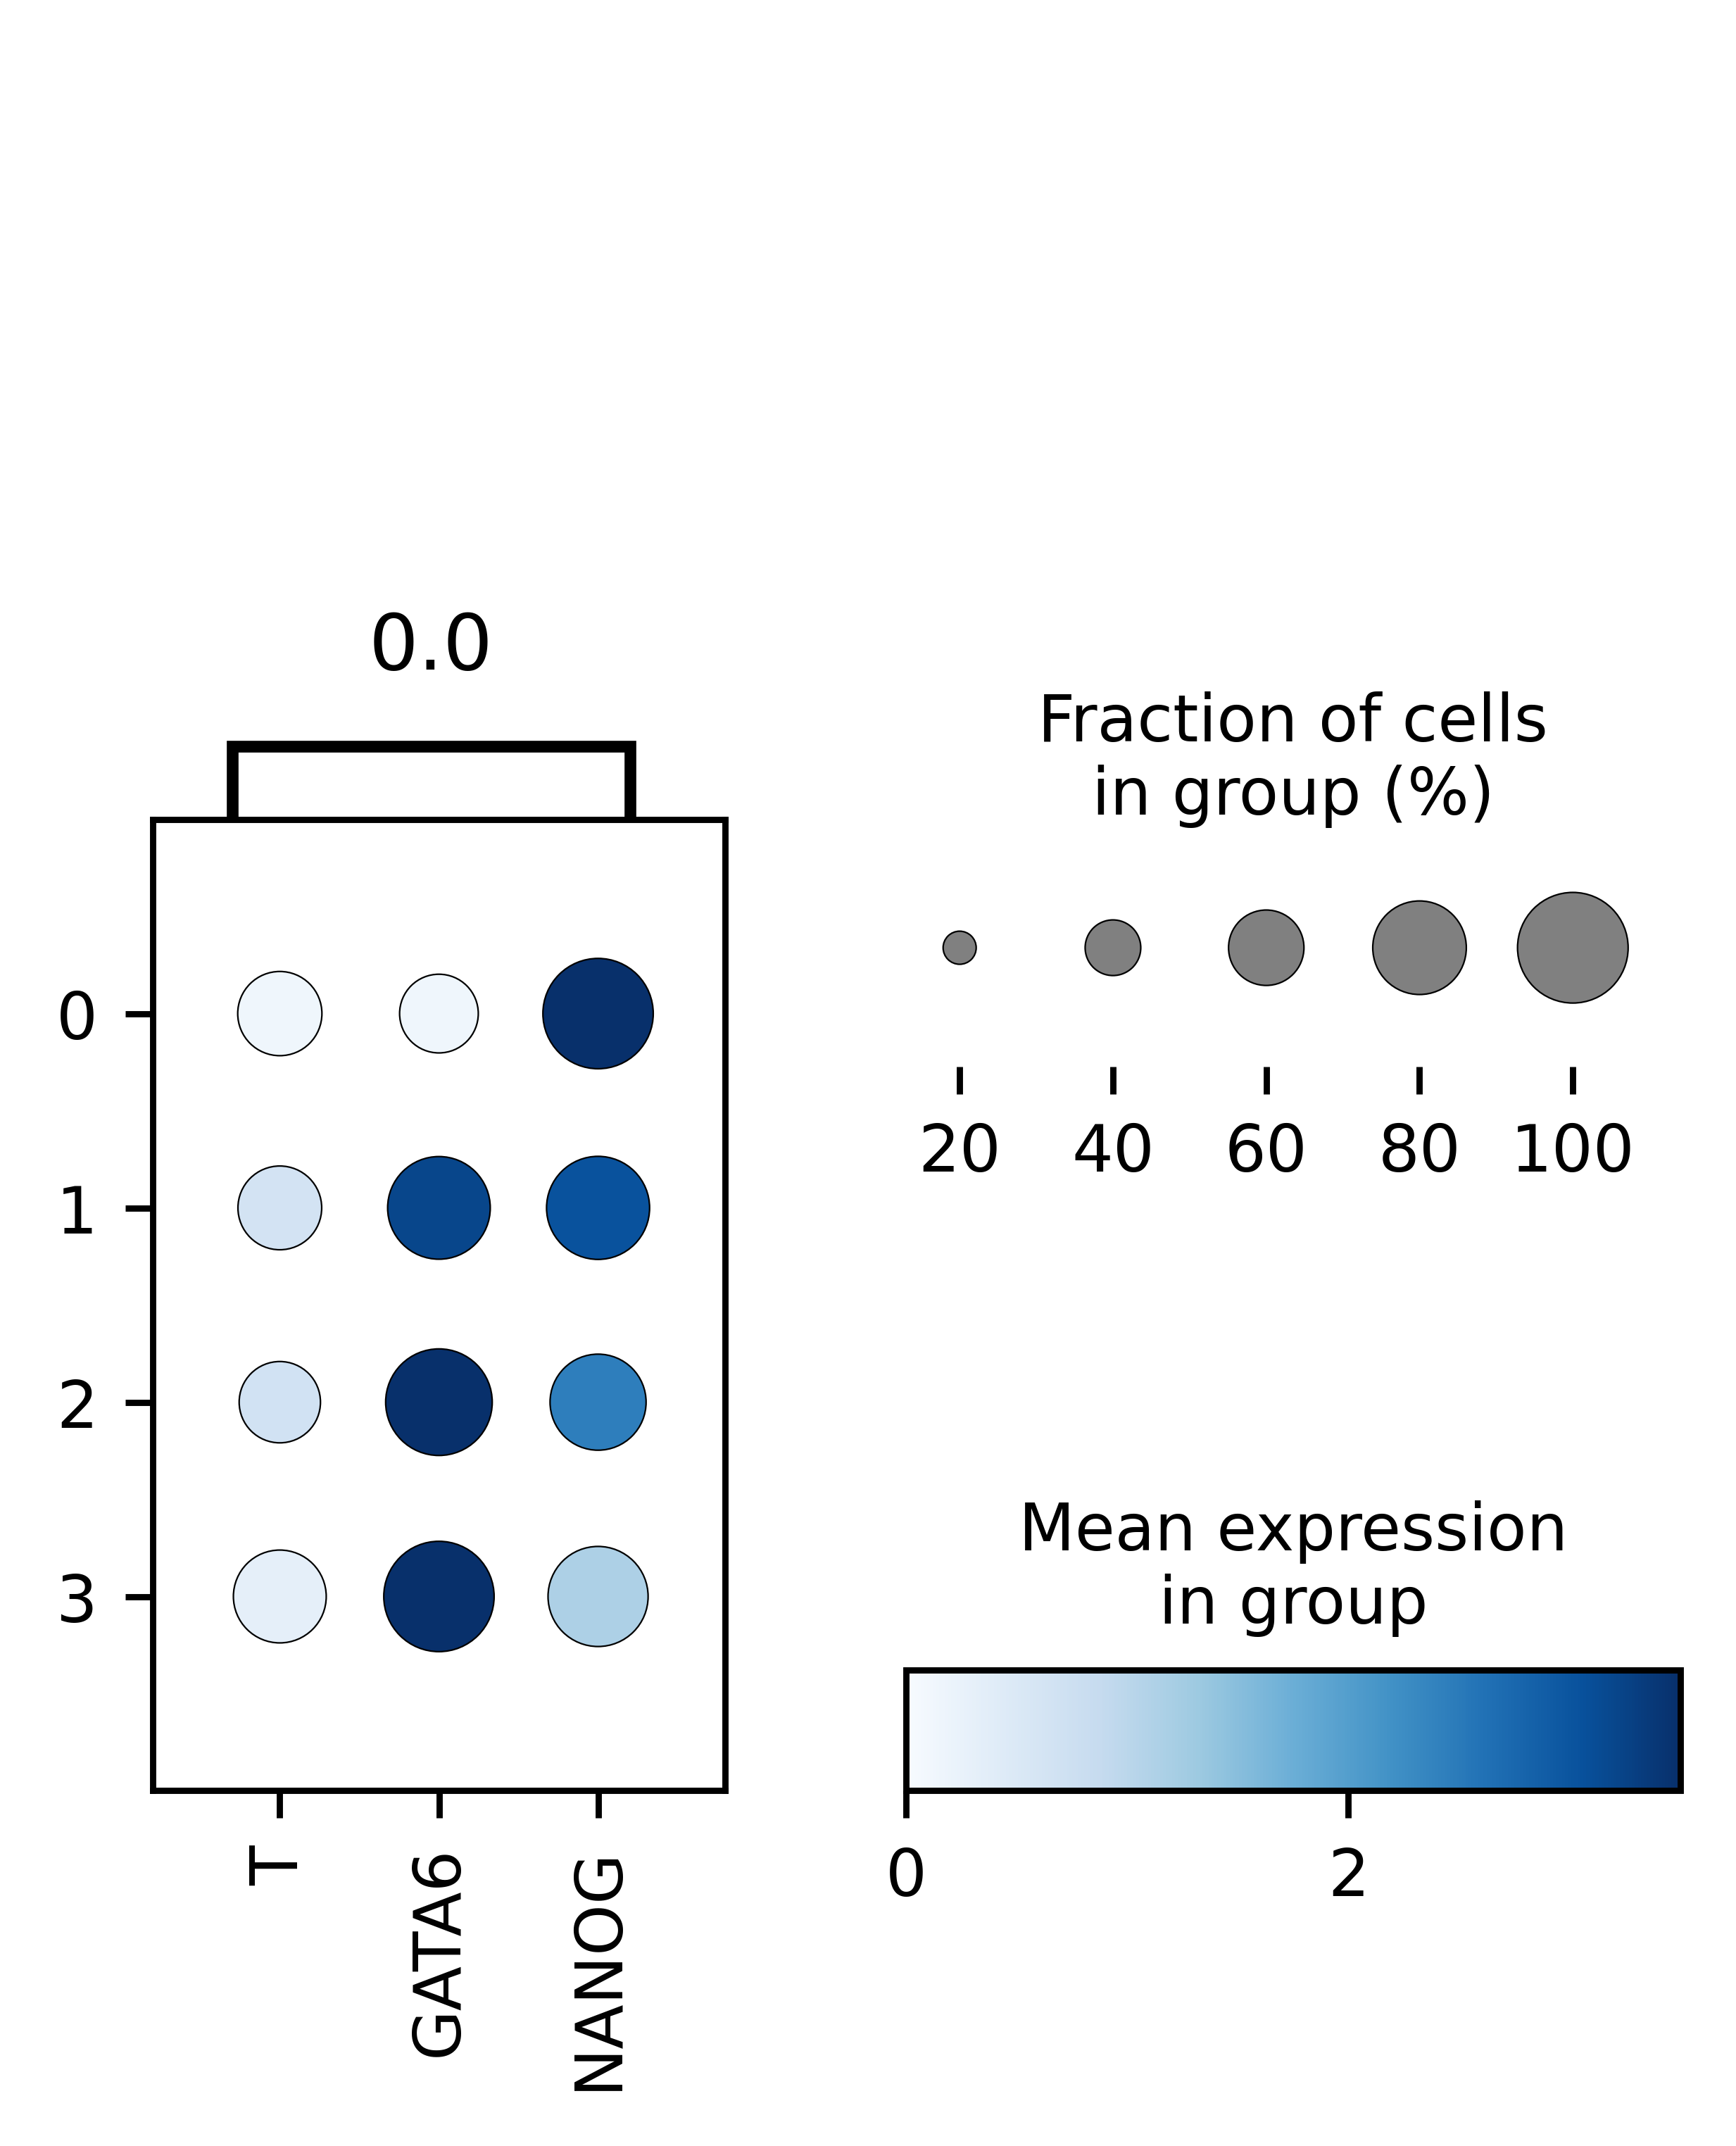

In [45]:
fig,ax = plt.subplots(figsize =(3.5,4),dpi=800)
sc.pl.dotplot(all_new_data, 
              marker_genes_dict, 'weights', 
              vmin=0,
              vmax=3.5,
              dendrogram=False,
              ax=ax,
              cmap='Blues',
             )

In [ ]:
# No pseudotime data provided in the code base, so the pseudotime plotting part is commented out.
# p_time = pd.read_csv('../Squidiff_project/figure2_dataset1_time_1022.csv',index_col=0)
# all_new_data.obs['Pseudotime'] = p_time.values

In [ ]:
# No pseudotime data provided in the code base, so the pseudotime plotting part is commented out.
# hex_colors = ['#3145a8', '#40a8f7', '#f5bf36','#fa2616']


# plt.figure(figsize=(3,1
#                    ),dpi=800)
# sns.kdeplot(data=all_new_data.obs, 
#             x="Pseudotime", 
#             hue="weights", 
#             bw_adjust=.8,
#             palette=hex_colors,
#             linewidth=2  ,  
#             common_norm=False)
# plt.legend().set_visible(False)
# plt.xlabel("Pseudotime")
# plt.ylabel("Density")
# plt.xlim([0,1])
# plt.show()